In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pandas as pd
import scipy.stats as stats

import os
import numpy as np
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
from quad_model import *
from tensorflow.keras.models import Model, load_model
from  tqdm import tqdm

#from interpretable_splicing.models import NucleotideStructureTunerCNN
import mukund_utils as utils

random.seed(100)
np.random.seed(100)



In [8]:
from joblib import dump

In [2]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
#model = NucleotideStructureTunerCNN.load_from_checkpoint(checkpoint_path='/home/andriy/PycharmProjects/interpretable_splicing/interpretable_splicing/model/random_seeds_hela/epoch=599_val_loss=0.099_rna_splicing_cnn_hela.yaml.ckpt')
model_keras = load_model('custom_adjacency_regularizer_20210731_124_step3.h5')

In [3]:
pre_tuner_model = Model(inputs=model_keras.inputs, outputs=model_keras.get_layer("energy_seq_struct").output)

In [4]:
ke_et_al_data = pd.read_excel("ke_et_al_Supplemental_Table_S2_no_empty_lines.xls")
ke_et_al_data["PSI"] = 0.19*ke_et_al_data.EI + 0.02
ke_et_al_data["es7_flanked_seq"] = ke_et_al_data.apply(lambda x: utils.add_flanking(x.seq[10:-10],10), axis=1)

In [5]:
ke_et_al_data["pre_tuner_predictions"] = pre_tuner_model(utils.create_input_data(list(ke_et_al_data.es7_flanked_seq))[:-1]).numpy().flatten()

In [6]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

def sigmoid_tuner(activations):
    return (sigmoid(np.array(model_keras.get_layer("gen_func")(np.array([[a] for a in activations]))).flatten()))


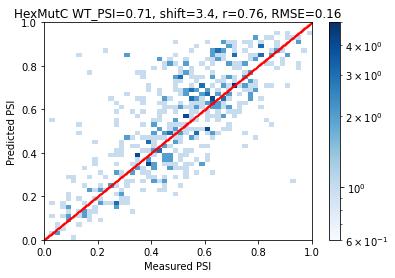

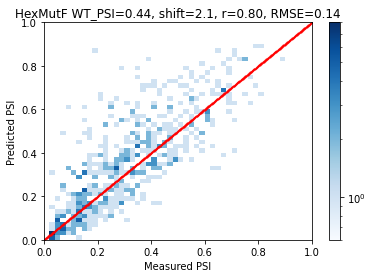

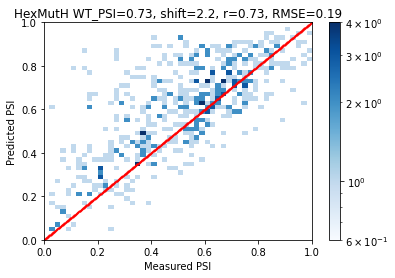

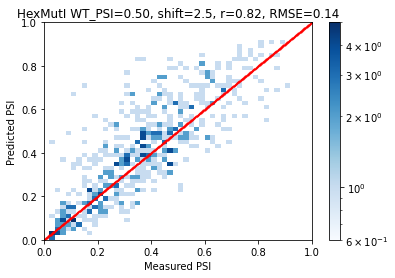

In [7]:
to_dump = []

for hex_mut in 'CFHI':
    filtered_data = ke_et_al_data[ke_et_al_data.Hexmut == hex_mut]
    
    wildtype_construct = filtered_data.iloc[0]

    # find the best shift so the wild type PSI matches the predicted PSI
    all_shifts = np.arange(-5,5,0.1)
    best_shift_index = np.argmin(np.abs(wildtype_construct.PSI - sigmoid_tuner(wildtype_construct.pre_tuner_predictions-np.array(all_shifts))))
    shift = all_shifts[best_shift_index]
    
    num_bins = 50
    #x = np.log(filtered_data.EI)
    x = (filtered_data.PSI)
    y = sigmoid_tuner(filtered_data.pre_tuner_predictions-shift)
    
    to_dump.append((x, y))
    
    #plt.hist(filtered_data.pre_tuner_predictions)
    #plt.show()
    plt.hist2d(x,y,range=[[0,1],[0,1]], bins=[num_bins,num_bins], cmap='Blues', norm=matplotlib.colors.LogNorm(vmin=0.6))
    plt.xlabel("Measured PSI")
    plt.ylabel("Predicted PSI")
    plt.colorbar()

    reg = stats.linregress(x , y)
    rmse = np.sqrt(((x-y)**2).mean())

    left,right = plt.xlim()
    grid = np.linspace(left,right,500)
    #plt.scatter(grid, reg.intercept + grid * reg.slope, s=1, c='r')
    plt.scatter(grid, grid, s=1, c='r')

    #plt.title(f"HexMut{hex_mut} WT_PSI = {wildtype_construct.PSI:.2f}, shift={shift:.1f}, Slope={reg.slope:.2f}, r={reg.rvalue:.2f}, RMSE={rmse:.2f}") # intercept = {reg.intercept:.2f}, 
    plt.title(f"HexMut{hex_mut} WT_PSI={wildtype_construct.PSI:.2f}, shift={shift:.1f}, r={reg.rvalue:.2f}, RMSE={rmse:.2f}") # intercept = {reg.intercept:.2f}, 

    plt.show()

In [9]:
dump(to_dump, './ke_et_al.pkl')

['./ke_et_al.pkl']